Importing the Dependencies


In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import metrics

Loading the dataset to pandas DataFrame



In [2]:
df = pd.read_csv('/content/data.csv')

print ( df)

                     date         price  bedrooms  bathrooms  sqft_living  \
0     2014-05-02 00:00:00  3.130000e+05       3.0       1.50         1340   
1     2014-05-02 00:00:00  2.384000e+06       5.0       2.50         3650   
2     2014-05-02 00:00:00  3.420000e+05       3.0       2.00         1930   
3     2014-05-02 00:00:00  4.200000e+05       3.0       2.25         2000   
4     2014-05-02 00:00:00  5.500000e+05       4.0       2.50         1940   
...                   ...           ...       ...        ...          ...   
4595  2014-07-09 00:00:00  3.081667e+05       3.0       1.75         1510   
4596  2014-07-09 00:00:00  5.343333e+05       3.0       2.50         1460   
4597  2014-07-09 00:00:00  4.169042e+05       3.0       2.50         3010   
4598  2014-07-10 00:00:00  2.034000e+05       4.0       2.00         2090   
4599  2014-07-10 00:00:00  2.206000e+05       3.0       2.50         1490   

      sqft_lot  floors  waterfront  view  condition  sqft_above  \
0       

**1-Initial Data Exploration **

In this section, a general overview of the dataset is provided to better understand its structure and the nature of the features.

*Columns*

date: The date the house was sold.

price: The sale price of the house (target variable).

bedrooms: Number of bedrooms.

bathrooms: Number of bathrooms

sqft_living: Total living area in square feet

sqft_lot: Total area of the lot in square feet.

floors: Number of floors in the house.

waterfront: Indicates whether the house has a waterfront view (1 = yes, 0 = no).

view: Quality of the view from the house (scale from 0 to 4).

condition: Overall condition of the house (rated from 1 = poor to 5 = excellent).

sqft_above: Square footage of the house above ground level (excludes basement).

sqft_basement: Square footage of the basement.

yr_built: The year the house was built.

yr_renovated: The year the house was renovated

street: Street address of the house.

city: City where the house is located.

statezip: State and ZIP code

country: Country where the house is located


In [3]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

In [4]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
df.shape

(4600, 18)

In [6]:
missing_values = df.isnull().sum()
missing_values=missing_values[missing_values>0]
if missing_values.empty:
    print("There are no missing values in any of the columns")
else:
    print("Columns with missing values:\n",missing_values)

There are no missing values in any of the columns


In [7]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [8]:
df.dtypes

,0
date,object
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,int64
view,int64
condition,int64


**2-Data Visualization**

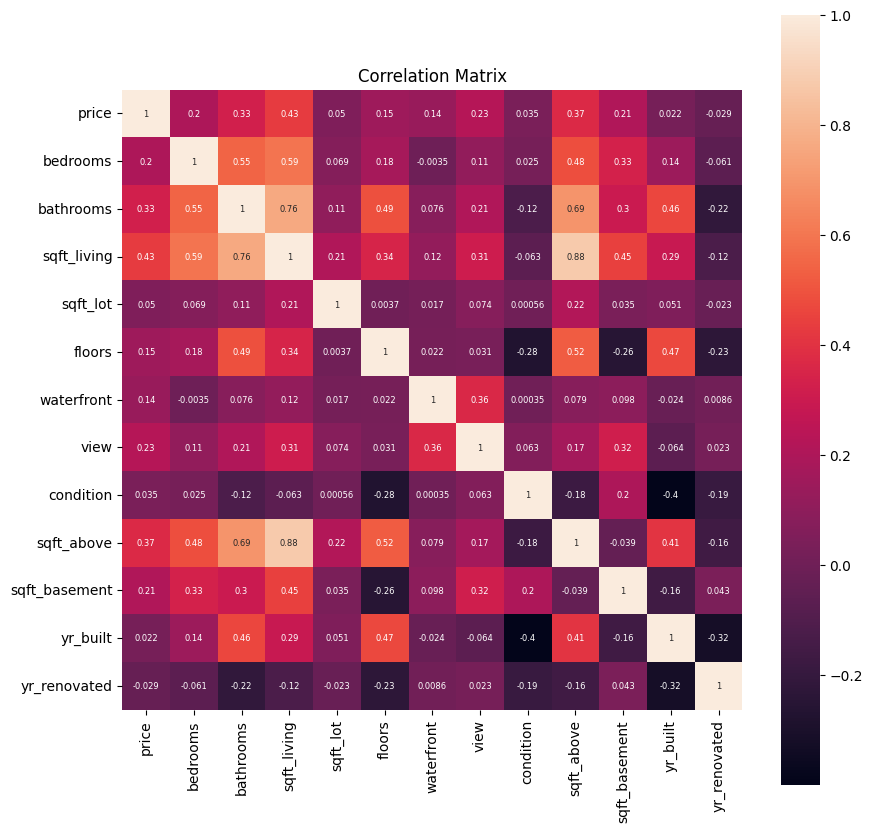

In [9]:
correlation_matrix = df.select_dtypes(include=['int64','float64']).corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, cbar=True, square=True, annot=True, annot_kws={'size': 6})
plt.title("Correlation Matrix")
plt.show()

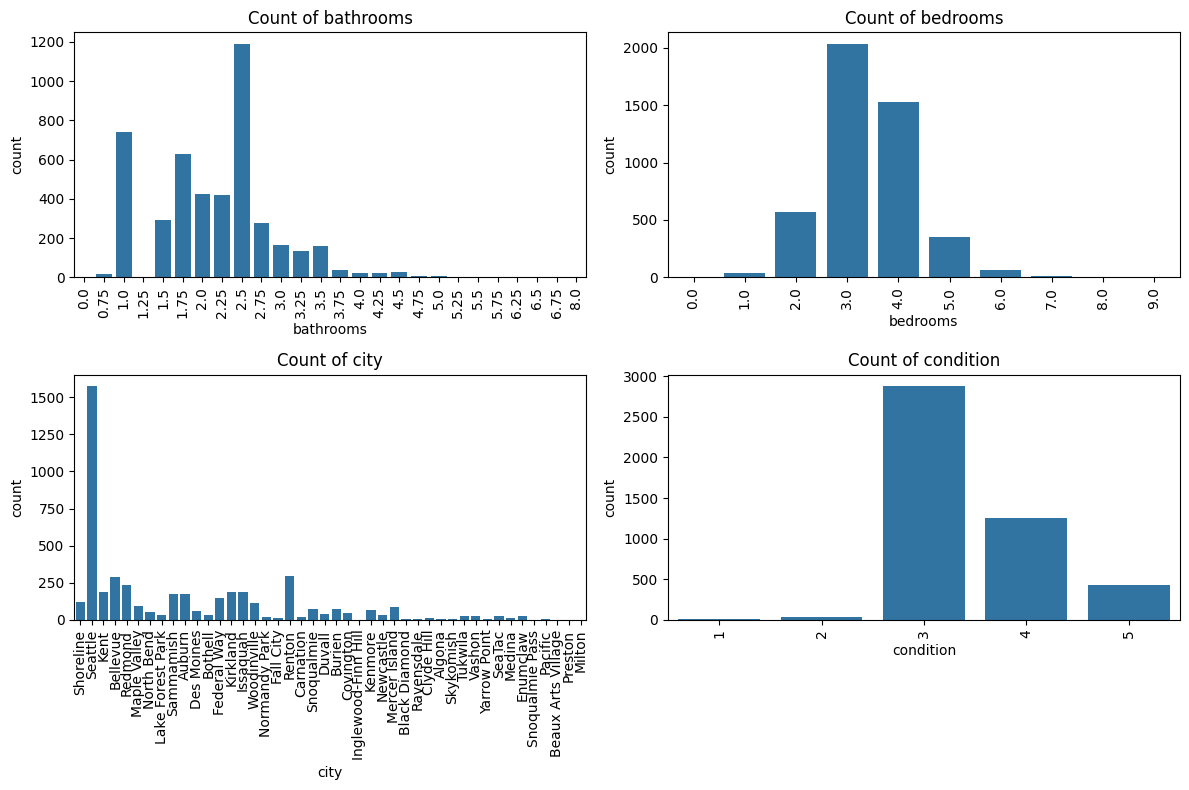

In [10]:
features=["bathrooms","bedrooms","city","condition"]

plt.figure(figsize=(12,8))
for i,feature in enumerate(features):
    plt.subplot(2,2,i+1)
    sns.countplot(x=feature,data=df)
    plt.title(f'Count of {feature}')
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

* Bathrooms

The majority of houses have between 1.0 and 2.5 bathrooms, with 2.5 being the most common. A small number of houses have more than 4 bathrooms, which suggests that larger or luxury homes are relatively rare.

* Bedrooms

Most houses have either 3 or 4 bedrooms, with 3 being the most common. Very few houses have more than 5 bedrooms, and a small number have only 1 or 2. This shows that mid-sized homes dominate the dataset.

* City*

The dataset includes houses from many different cities, but the majority of listings are concentrated in a few locations. For example, Seattle and Shoreline have the highest number of houses, while many cities have only a handful of listings. This suggests that the data is not evenly distributed across all cities.

* Condition

The vast majority of homes are rated as condition 3, followed by condition 4 and 5. Very few houses are rated as 1 or 2, meaning most homes are in average to good condition, and poorly maintained homes are rare in this dataset.

**3-Outlier Detection**

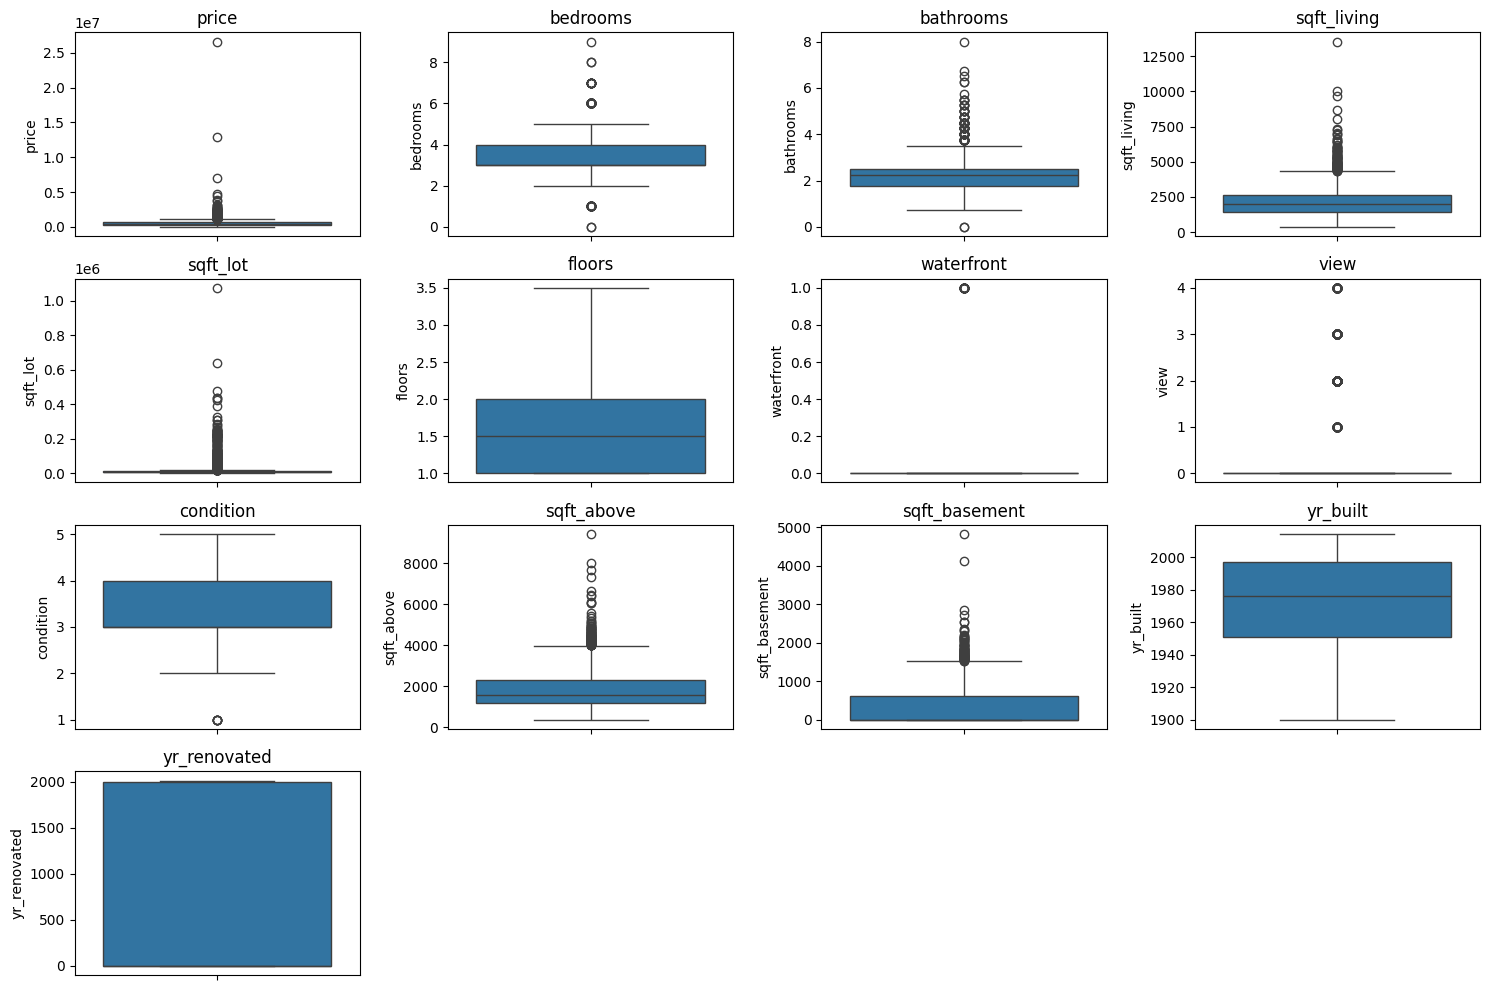

In [11]:
numeric_df=df.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(15,10))
for i,col in enumerate(numeric_df.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [12]:
df_cleaned=df.copy()

for col in numeric_df.columns:
    Q1=df_cleaned[col].quantile(0.25)
    Q3=df_cleaned[col].quantile(0.75)
    IQR=Q3-Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]

print(f"Original dataset shape: {df.shape}")
print(f"Cleaned dataset shape: {df_cleaned.shape}")

Original dataset shape: (4600, 18)
Cleaned dataset shape: (3316, 18)


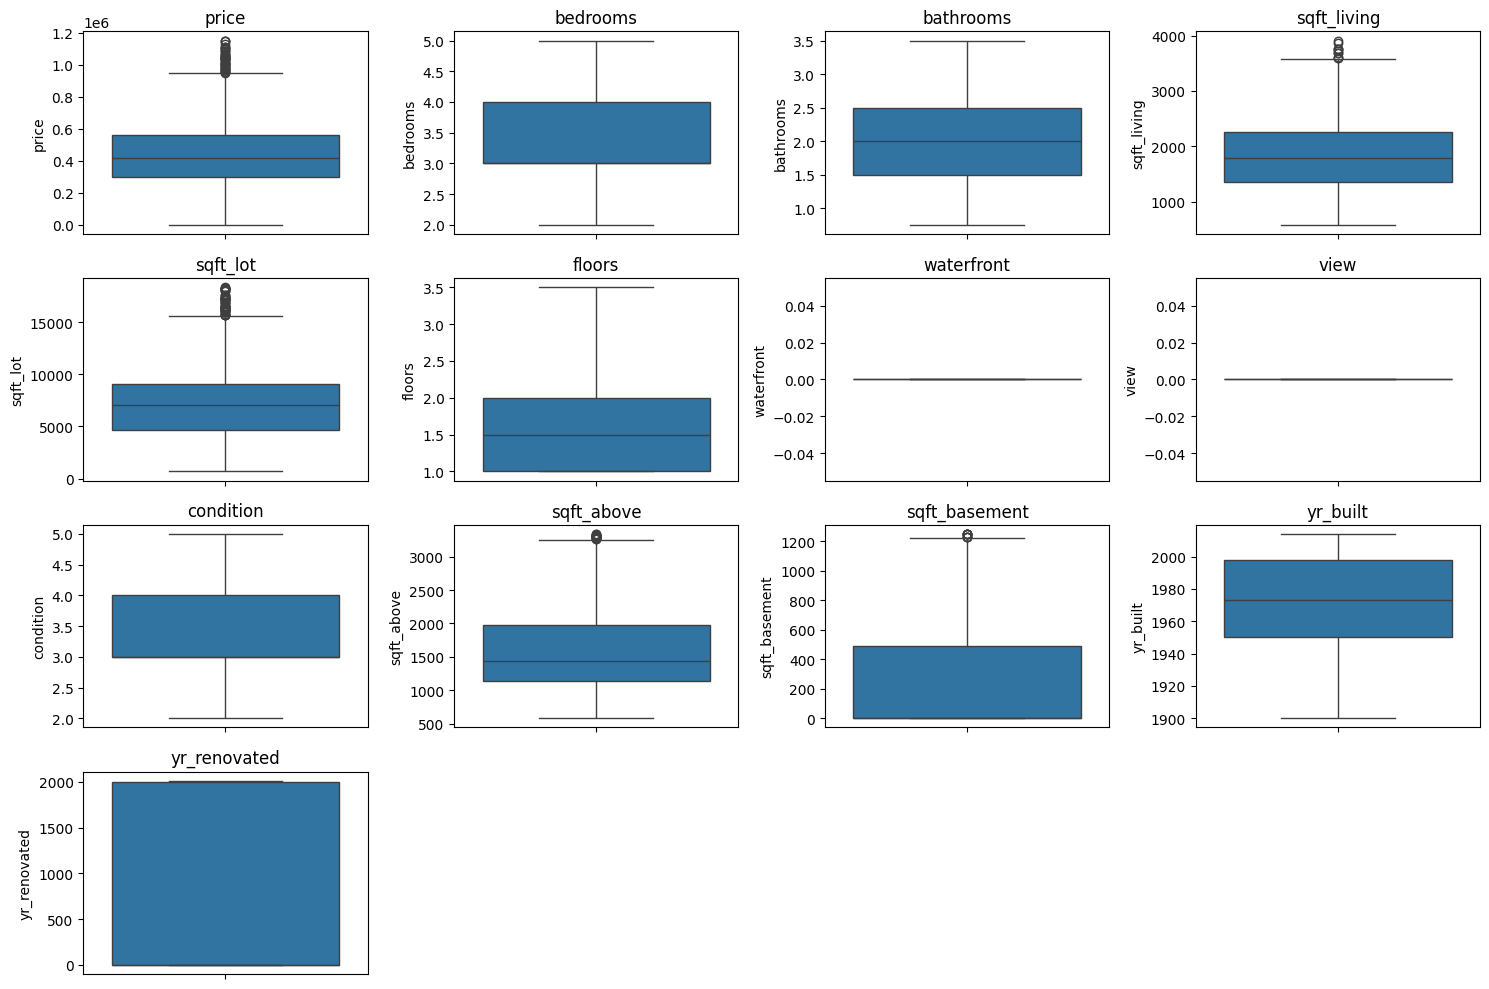

In [13]:
numeric_df=df_cleaned.select_dtypes(include=["int64","float64"])

plt.figure(figsize=(15,10))
for i,col in enumerate(numeric_df.columns):
    plt.subplot(4,4,i+1)
    sns.boxplot(y=df_cleaned[col])
    plt.title(col)

plt.tight_layout()
plt.show()

*OneHot Encoding*

In [37]:
df_encoded = pd.get_dummies(df_cleaned, columns=['city', 'statezip', 'country'], drop_first=True)


**4-Building the Model**

*Splitting the data and Target*

In [38]:
df = df_encoded.copy()

df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

X = df.drop(['price','date'], axis = 1)
Y = df['price']
print(X)
print(Y)

      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  \
0          3.0       1.50         1340      7912     1.5           0     0   
2          3.0       2.00         1930     11947     1.0           0     0   
3          3.0       2.25         2000      8030     1.0           0     0   
4          4.0       2.50         1940     10500     1.0           0     0   
5          2.0       1.00          880      6380     1.0           0     0   
...        ...        ...          ...       ...     ...         ...   ...   
4595       3.0       1.75         1510      6360     1.0           0     0   
4596       3.0       2.50         1460      7573     2.0           0     0   
4597       3.0       2.50         3010      7014     2.0           0     0   
4598       4.0       2.00         2090      6630     1.0           0     0   
4599       3.0       2.50         1490      8102     2.0           0     0   

      condition  sqft_above  sqft_basement  ...  statezip_WA 98

*Splitting the data into Training and Test*

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, Y , test_size=0.2, random_state=42)
print(X_train.shape , y_train.shape , X_test.shape)

(2652, 133) (2652,) (664, 133)


In [40]:
print(X_train.select_dtypes(include="object").columns)

Index(['street'], dtype='object')


In [41]:
X_train = X_train.select_dtypes(include=["int64", "float64"])
X_test = X_test.select_dtypes(include=["int64", "float64"])

*Model Training*

In [42]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Loading the models :

models = {
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

#Training the models :

for  model in models.values():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)



*Evaluation*

In [44]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = mse ** 0.5
    r2 = r2_score(y_test, y_pred)

    print(f"{name} Results:")
    print(f"  ➤ RMSE     : {rmse:.2f}")
    print(f"  ➤ R2 Score : {r2:.2f}")



Decision Tree Results:
  ➤ RMSE     : 207836.16
  ➤ R2 Score : -0.13
Random Forest Results:
  ➤ RMSE     : 148211.33
  ➤ R2 Score : 0.42
Gradient Boosting Results:
  ➤ RMSE     : 141561.28
  ➤ R2 Score : 0.47
XGBoost Results:
  ➤ RMSE     : 156989.90
  ➤ R2 Score : 0.35


*Model Performance Summary:*

- Decision Tree Regressor
Achieved an RMSE of approximately 207,836.16 and an R² score of -0.13, indicating poor predictive power and likely overfitting on the training data.

- Random Forest Regressor
Yielded an RMSE of approximately 148,211.33 and an R² score of 0.42, showing reasonable performance with better generalization than a single decision tree.

- Gradient Boosting Regressor
- Gradient Boosting Regressor
Received an RMSE of around 141,561.28 and an R² score of 0.47, with the highest performance among the four models tried, with relatively high explanatory power and accuracy.

- XGBoost Regressor
Received an RMSE of around 156,989.90 and an R² score of 0.35, with worse performance than Gradient Boosting and Random Forest, possibly due to bad hyperparameters or a lack of tuning.

--> Conclusion: The top-performing model of the compared models was Gradient Boosting Regressor on the test set. Random Forest also gave reasonable results, while XGBoost may require some additional tuning to outperform the others. Decision Tree, as expected, performed worst due to its simplicity and high variance.

**Visualisation the actuel prices vs predicted prices **


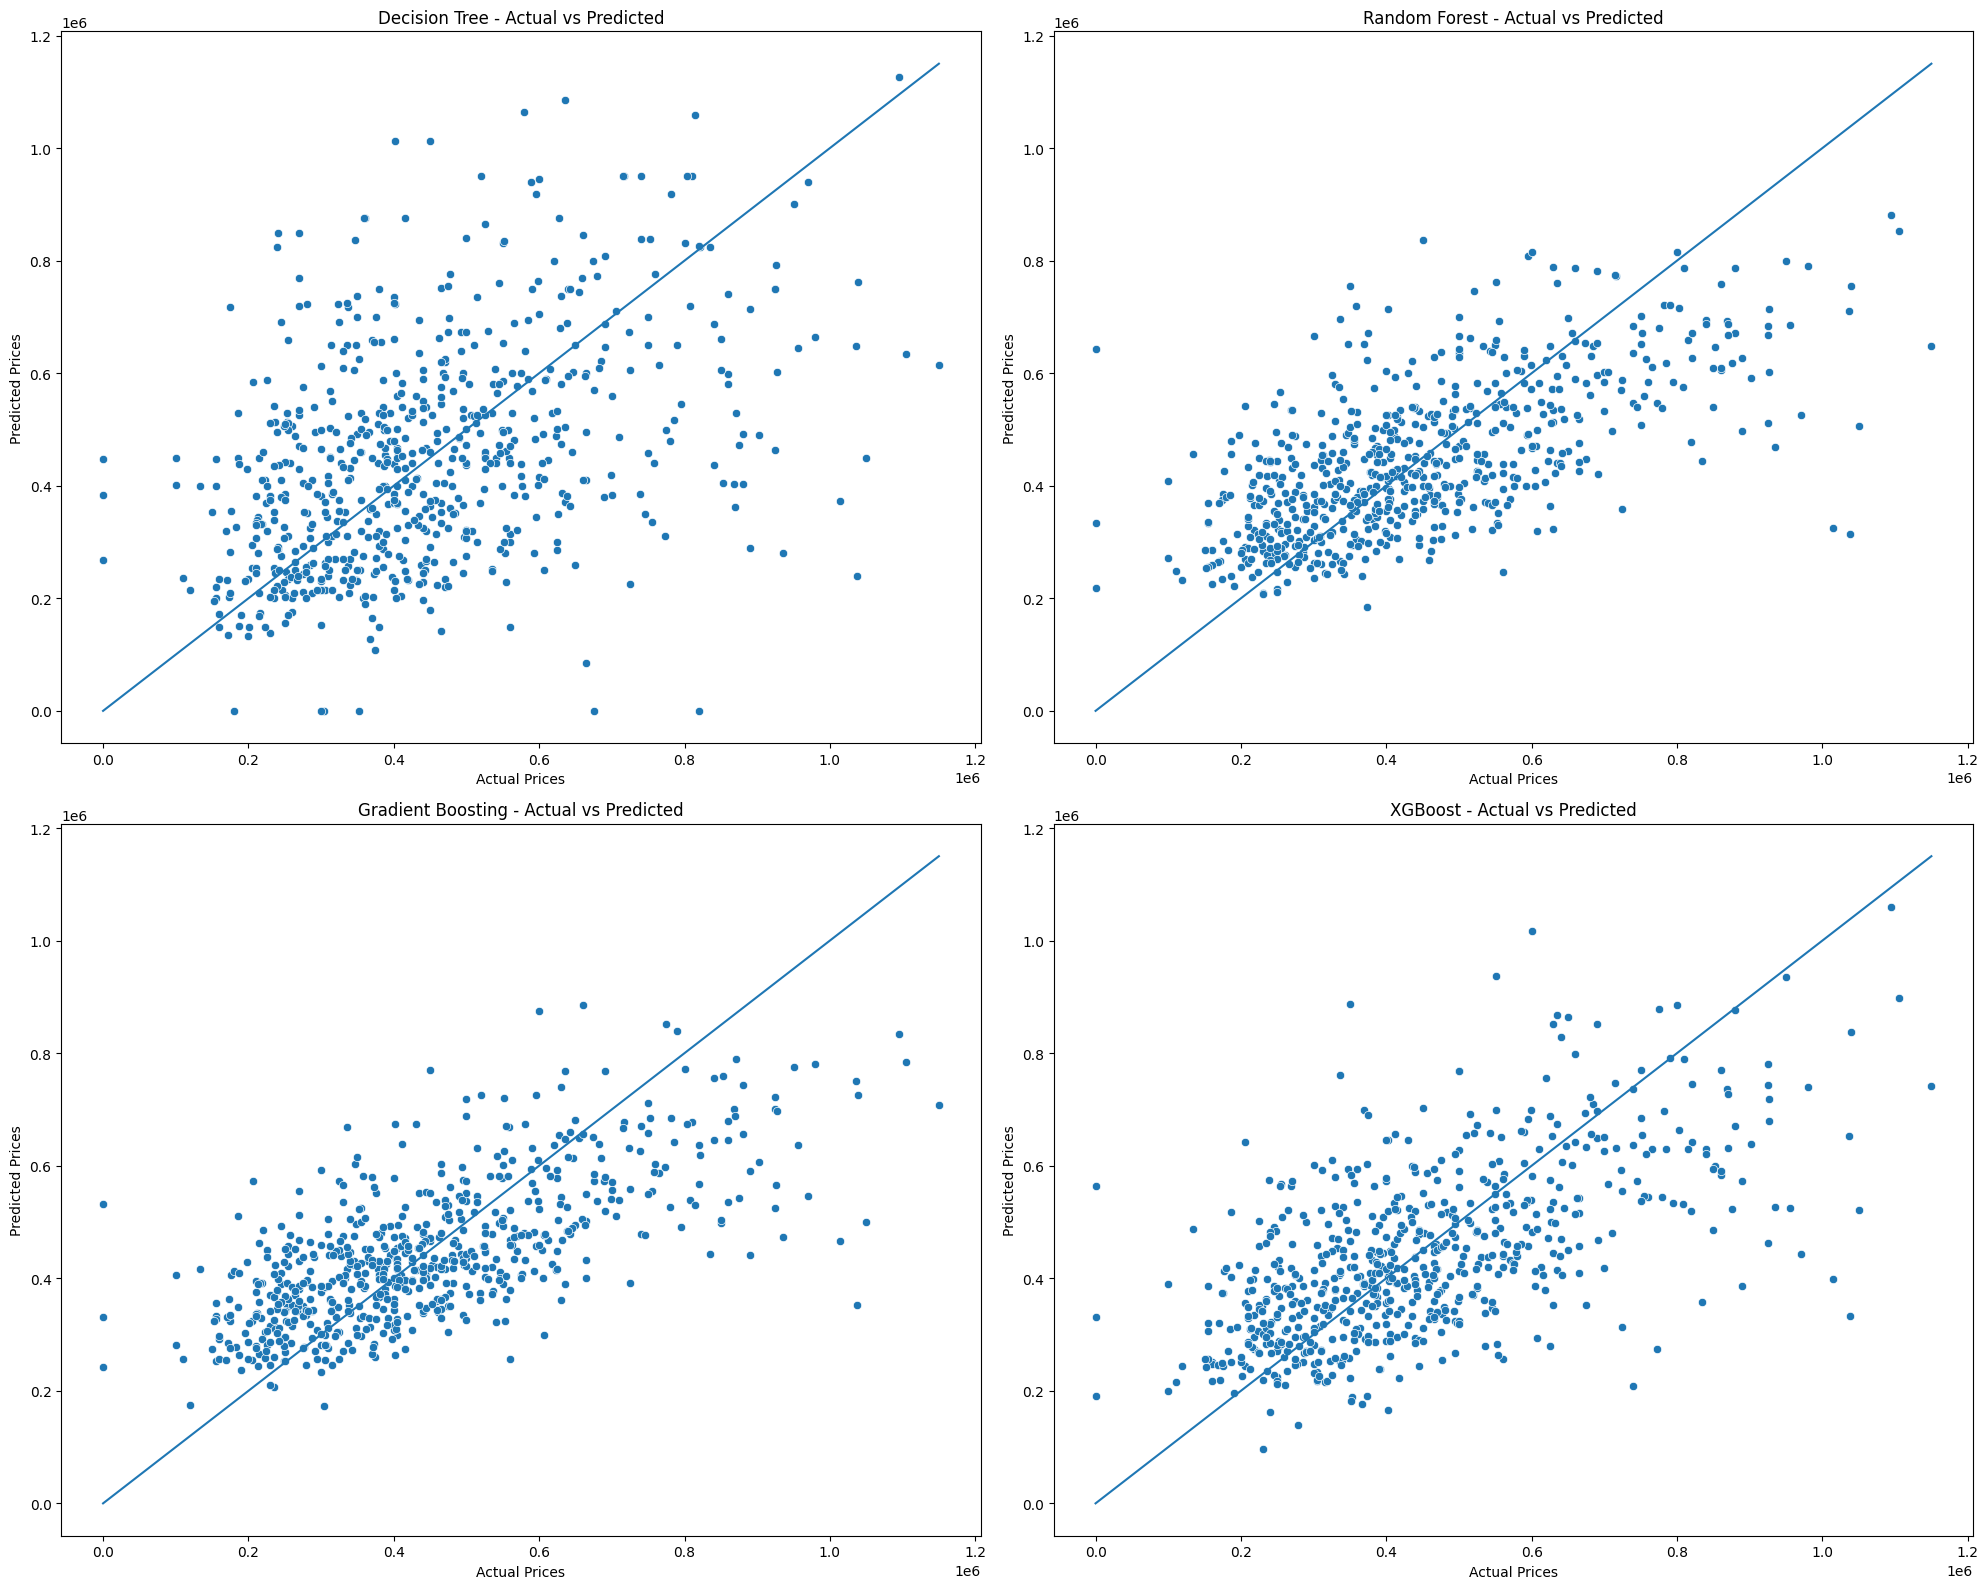

In [49]:
plt.figure(figsize=(20, 16))

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Scatter plot: actual vs predicted
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=y_test, y=y_pred)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])  # Diagonal line
    plt.title(f'{name} - Actual vs Predicted')
    plt.xlabel('Actual Prices')
    plt.ylabel('Predicted Prices')

plt.tight_layout()
plt.show()


The scatter plots of actual vs predicted prices for each model give us a visual sense of their prediction accuracy.

- Decision Tree: The points are widely scattered around the diagonal line, indicating poor fit and likely overfitting. The model does not generalize well on test data.

- Random Forest: Points are more tightly clustered along the diagonal, showing better prediction accuracy compared to the simple decision tree.

- Gradient Boosting: Points are even closer to the diagonal, reflecting improved precision and a stronger ability to capture complex relationships in the data.

- XGBoost: The points show good alignment overall, but in this case slightly more spread than Gradient Boosting, suggesting hyperparameter tuning could further enhance its performance.

